In [2]:
import pandas as pd
import numpy as np
import os

processed_path = os.path.join("..", "Data", "Processed")

transactions = pd.read_csv(os.path.join(processed_path, "transactions_clean.csv"))
transactions['InvoiceDate'] = pd.to_datetime(transactions['InvoiceDate'])
transactions.shape

(805549, 11)

In [3]:
monetary = transactions.groupby('Customer ID')['TotalPrice'].sum().rename('Monetary')
monetary.head()

Customer ID
12346    77556.46
12347     5633.32
12348     2019.40
12349     4428.69
12350      334.40
Name: Monetary, dtype: float64

In [4]:
monetary = transactions.groupby('Customer ID')['TotalPrice'].sum().rename('Monetary')
monetary.head()

Customer ID
12346    77556.46
12347     5633.32
12348     2019.40
12349     4428.69
12350      334.40
Name: Monetary, dtype: float64

In [5]:
frequency = transactions.groupby('Customer ID')['Invoice'].nunique().rename('Frequency')
frequency.head()

Customer ID
12346    12
12347     8
12348     5
12349     4
12350     1
Name: Frequency, dtype: int64

In [6]:
last_purchase = transactions.groupby('Customer ID')['InvoiceDate'].max().rename('Last_Purchase_Date')

reference_date = transactions['InvoiceDate'].max() + pd.Timedelta(days=1)
reference_date

Timestamp('2011-12-10 12:50:00')

In [7]:
recency = (reference_date - last_purchase).dt.days.rename('Recency')
recency.head()

Customer ID
12346    326
12347      2
12348     75
12349     19
12350    310
Name: Recency, dtype: int64

In [8]:
customer_features = pd.concat([recency, frequency, monetary], axis=1)
customer_features.head()

,Recency,Frequency,Monetary
Customer ID,,,
12346,326,12,77556.46
12347,2,8,5633.32
12348,75,5,2019.40
12349,19,4,4428.69
12350,310,1,334.40


In [9]:
cancel_count_per_customer = transactions.groupby('Customer ID')['Cancel_Count'].first().rename('Cancel_Count')

customer_features = pd.concat([customer_features, cancel_count_per_customer], axis=1)
customer_features = customer_features.reset_index()

customer_features.head()
customer_features.describe()

,Customer ID,Recency,Frequency,Monetary,Cancel_Count
count,5878.000000,5878.000000,5878.000000,5878.000000,5878.000000
mean,15315.313542,201.331916,6.289384,3018.616737,3.166894
std,1715.572666,209.338707,13.009406,14737.731040,11.466497
min,12346.000000,1.000000,1.000000,2.950000,0.000000
25%,13833.250000,26.000000,1.000000,348.762500,0.000000
50%,15314.500000,96.000000,3.000000,898.915000,0.000000
75%,16797.750000,380.000000,7.000000,2307.090000,2.000000
max,18287.000000,739.000000,398.000000,608821.650000,366.000000


In [10]:
import numpy as np
from sklearn.preprocessing import StandardScaler

# Log-transform to reduce skew (add 1 to avoid log(0) errors)
rfm_log = customer_features[['Recency', 'Frequency', 'Monetary']].apply(lambda x: np.log1p(x))

# Standardize so all features are on comparable scales for K-means
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_log)

rfm_scaled[:5]

array([[ 0.85670058,  1.25449595,  3.18662493],
       [-2.15197903,  0.80016603,  1.2971269 ],
       [-0.07913835,  0.29920733,  0.55810028],
       [-0.93530818,  0.07394609,  1.12379048],
       [ 0.82452706, -1.05814595, -0.73588827]])

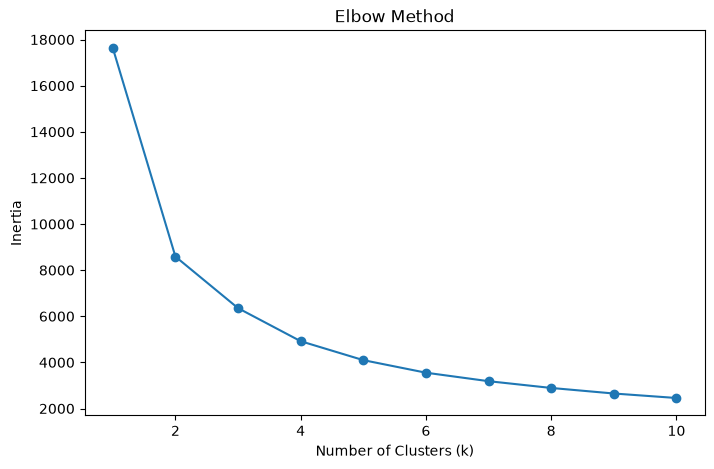

In [11]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []
k_range = range(1, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(rfm_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(k_range, inertia, marker='o')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()

In [12]:
from sklearn.metrics import silhouette_score

for k in range(4, 7):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(rfm_scaled)
    score = silhouette_score(rfm_scaled, labels)
    print(f"k={k}, silhouette score={score:.4f}")

k=4, silhouette score=0.3653
k=5, silhouette score=0.3421
k=6, silhouette score=0.3336


In [13]:
kmeans_final = KMeans(n_clusters=4, random_state=42, n_init=10)
customer_features['Cluster'] = kmeans_final.fit_predict(rfm_scaled)

customer_features['Cluster'].value_counts()

Cluster
1    1974
2    1465
3    1251
0    1188
Name: count, dtype: int64

In [14]:
cluster_profile = customer_features.groupby('Cluster')[['Recency', 'Frequency', 'Monetary', 'Cancel_Count']].mean().round(1)
cluster_profile

,Recency,Frequency,Monetary,Cancel_Count
Cluster,,,,
0,27.4,19.3,11014.4,10.5
1,395.9,1.4,325.7,0.5
2,227.9,5.1,2002.1,2.6
3,28.4,3.0,865.1,1.0


In [15]:
cluster_names = {
    0: 'Champions',
    1: 'Lost/Inactive',
    2: 'At-Risk',
    3: 'New/Occasional'
}

customer_features['Segment'] = customer_features['Cluster'].map(cluster_names)
customer_features.head()

customer_features.to_csv(os.path.join(processed_path, "customer_segments.csv"), index=False)

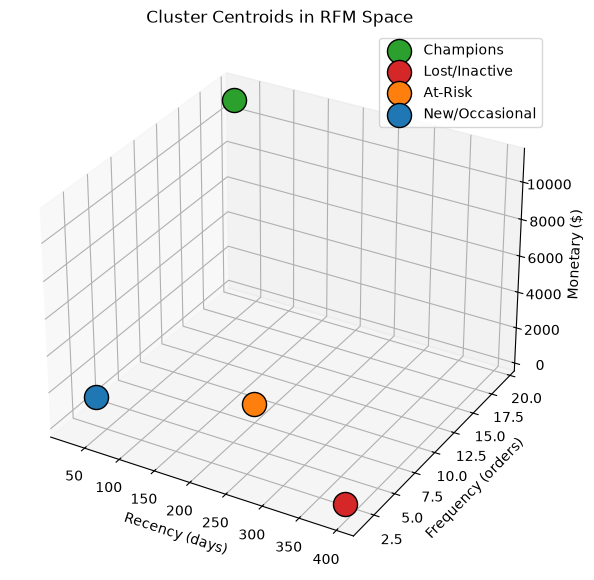

In [16]:
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection='3d')

colors = ['#2ca02c', '#d62728', '#ff7f0e', '#1f77b4']  # green, red, orange, blue

for cluster_id, name in cluster_names.items():
    row = cluster_profile.loc[cluster_id]
    ax.scatter(row['Recency'], row['Frequency'], row['Monetary'],
               s=300, color=colors[cluster_id], label=name, edgecolor='black')

ax.set_xlabel('Recency (days)')
ax.set_ylabel('Frequency (orders)')
ax.set_zlabel('Monetary ($)')
ax.set_title('Cluster Centroids in RFM Space')
ax.legend()

plt.show()